<a href="https://colab.research.google.com/github/aaiissss/Machine-Learning/blob/Pertemuan06/Tugas06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

In [3]:
#Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Praktikum_ML/Praktikum06/Data/data.csv")
print("5 Data Teratas:")
print(df.head())
print("\nInfo Dataset:")
print(df.info())
print("\nStatistika Deskriptif:")
print(df.describe())

5 Data Teratas:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_w

In [7]:
#Cek Nilai Unik pada Kolom Target
if "diagnosis" in df.columns:
    print("\nNilai unik pada kolom diagnosis:", df["diagnosis"].unique())
    print("\nJumlah data tiap kelas:")
    print(df["diagnosis"].value_counts())
else:
    print("\nKolom target tidak bernama 'diagnosis'. Pastikan kolom target diketahui.")


Nilai unik pada kolom diagnosis: ['M' 'B']

Jumlah data tiap kelas:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [15]:
# Drop unnecessary columns and rows with NaNs from the original dataframe
df_cleaned = df.drop(["id", "Unnamed: 32"], axis=1).dropna()

#Pisahkan Fitur (X) dan Label (y) from the cleaned dataframe
X = df_cleaned.drop("diagnosis", axis=1)
y = df_cleaned["diagnosis"]

In [17]:
#Split Data (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Explicitly handle NaNs in train and test sets after splitting
X_train = X_train.dropna()
y_train = y_train[X_train.index] # Ensure y_train is aligned with X_train

X_test = X_test.dropna()
y_test = y_test[X_test.index] # Ensure y_test is aligned with X_test

In [14]:
print("\nChecking for NaN values in X_train:")
print(X_train.isnull().sum().sum())


Checking for NaN values in X_train:
455


In [24]:
print("\nAkurasi Model:", accuracy_score(y_test_encoded, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))


Akurasi Model: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [23]:
#Make predictions on the scaled testing data
y_pred = model.predict(X_test_scaled)

In [19]:
from sklearn.preprocessing import StandardScaler

# Encode target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check for NaN values after scaling
print("\nChecking for NaN values in X_train after scaling:")
print(np.isnan(X_train_scaled).sum())
print("\nChecking for NaN values in X_test after scaling:")
print(np.isnan(X_test_scaled).sum())


Checking for NaN values in X_train after scaling:
0

Checking for NaN values in X_test after scaling:
0


In [20]:
# Instantiate SVC model
model = SVC()

# Fit the model
model.fit(X_train_scaled, y_train_encoded)

SVC()

In [21]:
#Make predictions on the scaled testing data
y_pred = model.predict(X_test_scaled)

In [22]:
# Calculate and print the accuracy score
print("\nAkurasi Model:", accuracy_score(y_test_encoded, y_pred))

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))

# Calculate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))


Akurasi Model: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[71  0]
 [ 2 41]]


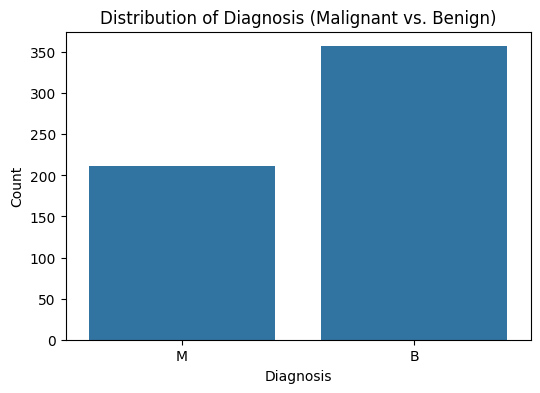

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis (Malignant vs. Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

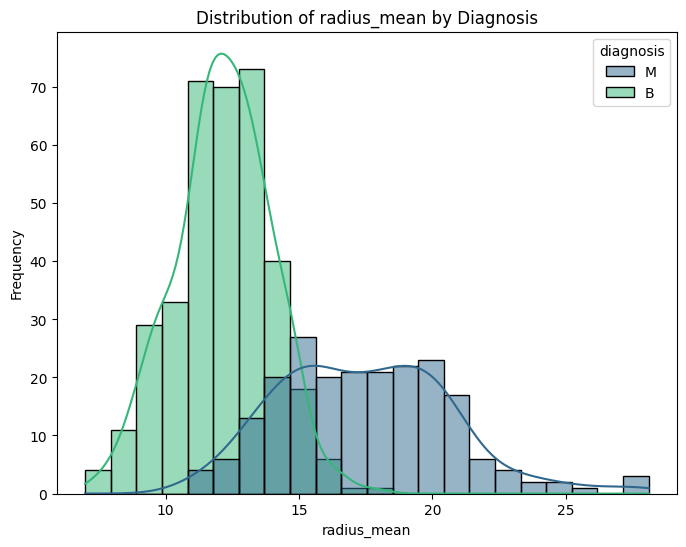

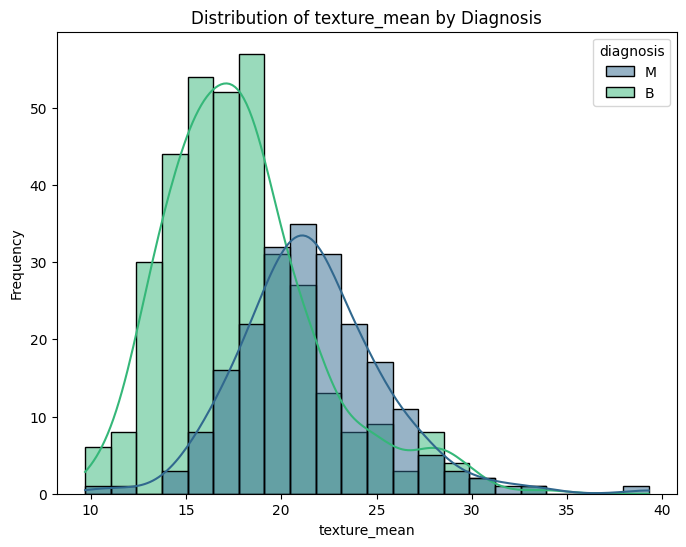

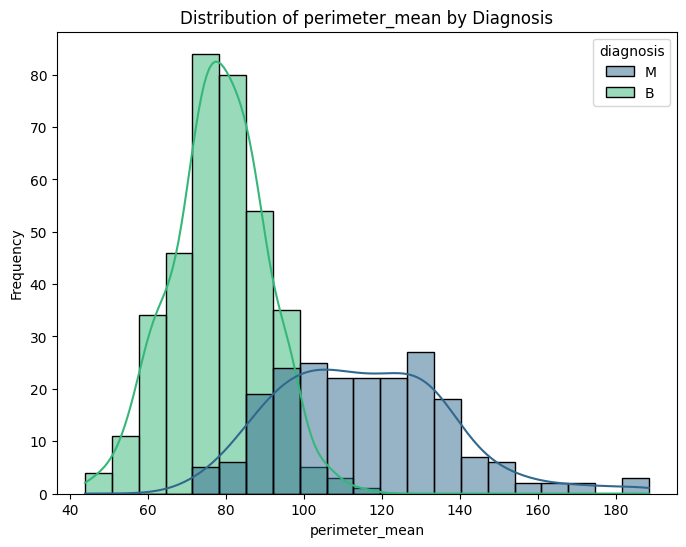

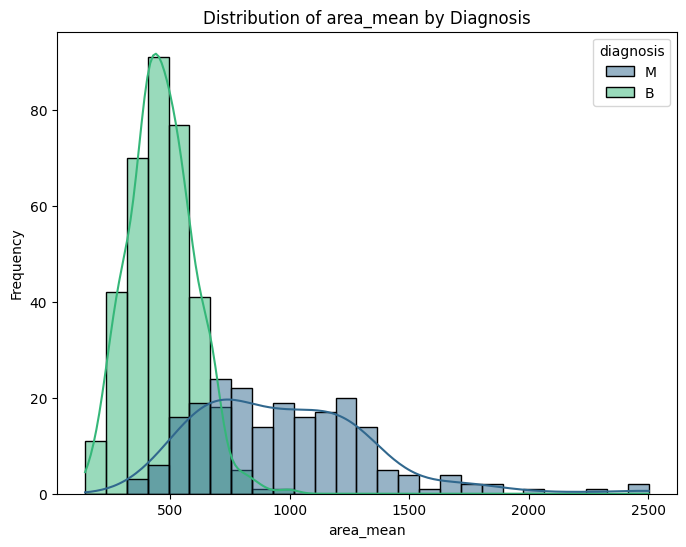

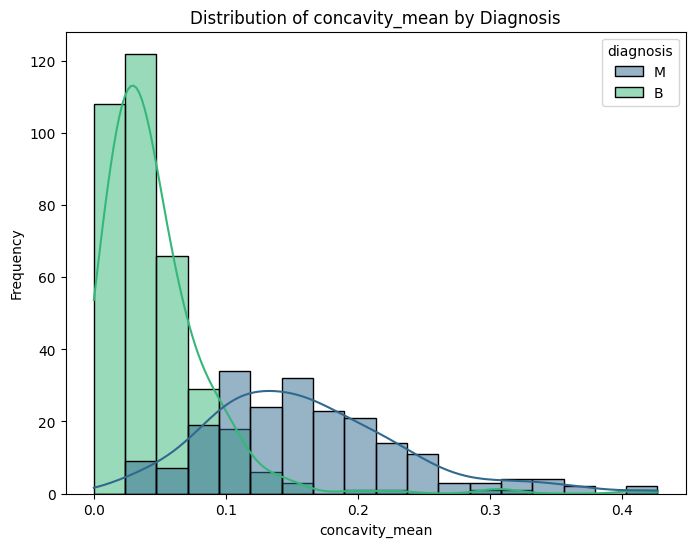

/tmp/ipython-input-3509067143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')


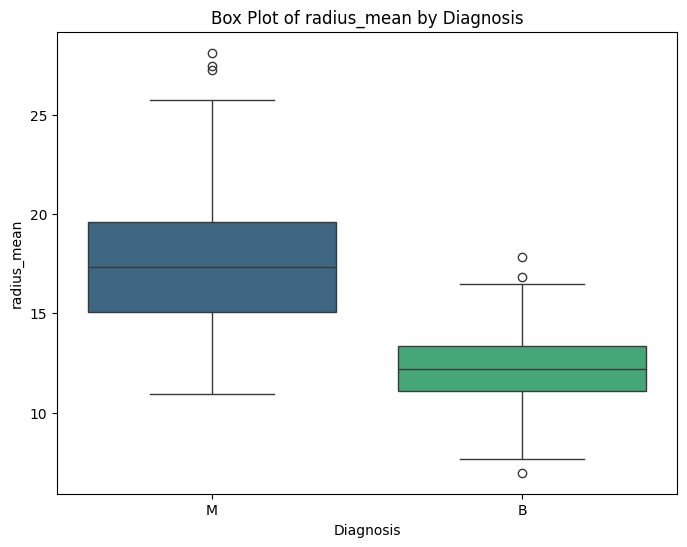

/tmp/ipython-input-3509067143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')


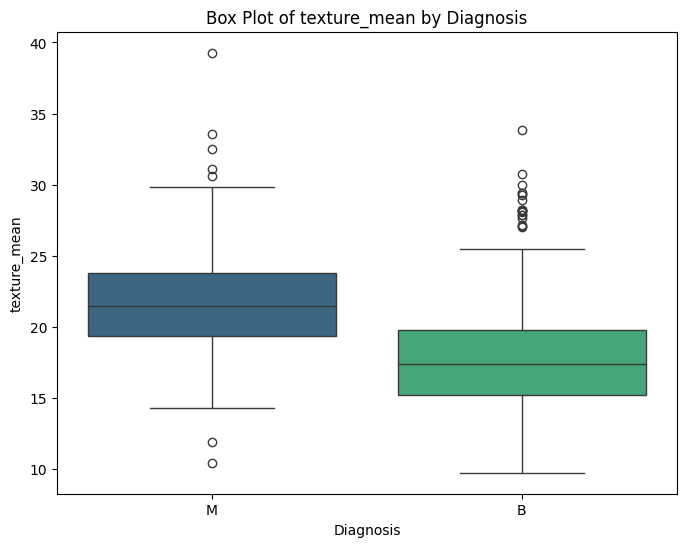

/tmp/ipython-input-3509067143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')


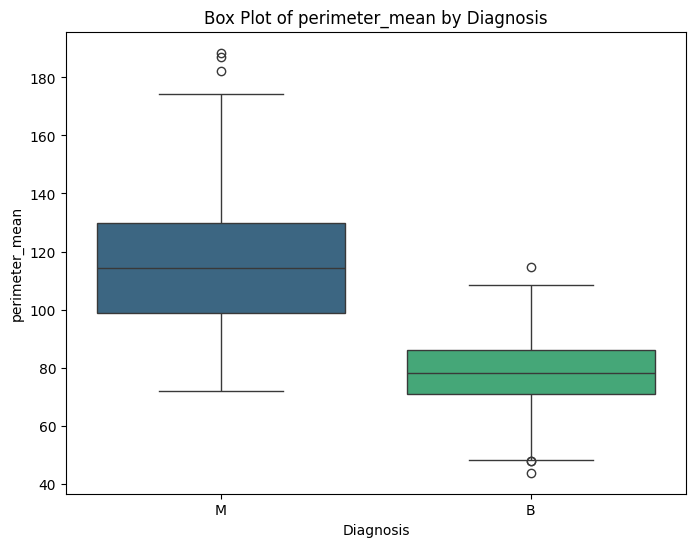

/tmp/ipython-input-3509067143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')


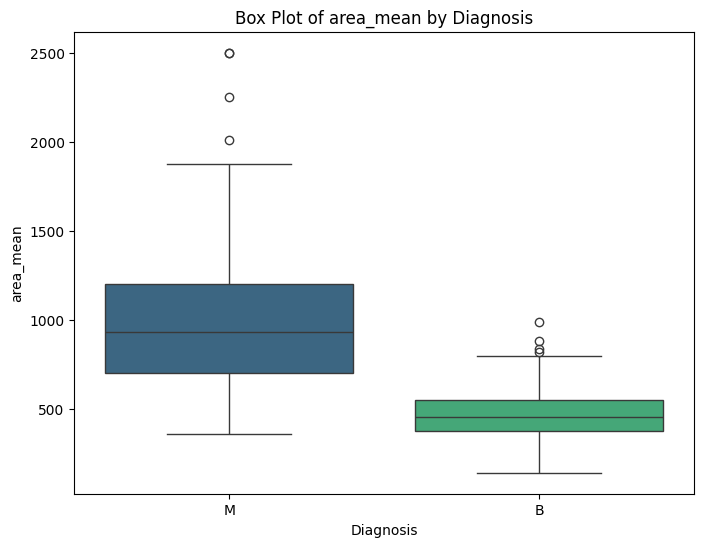

/tmp/ipython-input-3509067143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')


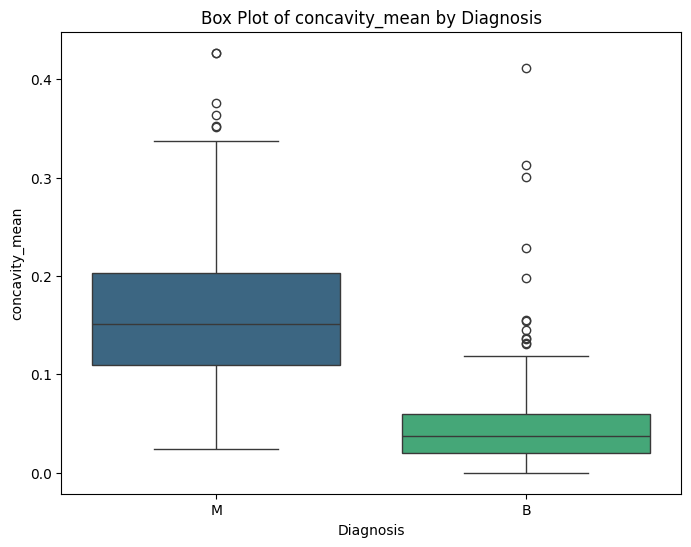

In [26]:
# Select a few relevant features for visualization
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean']

# Create visualizations for each selected feature
for feature in selected_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df_cleaned, x=feature, hue='diagnosis', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature} by Diagnosis')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

for feature in selected_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_cleaned, x='diagnosis', y=feature, palette='viridis')
    plt.title(f'Box Plot of {feature} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(feature)
    plt.show()

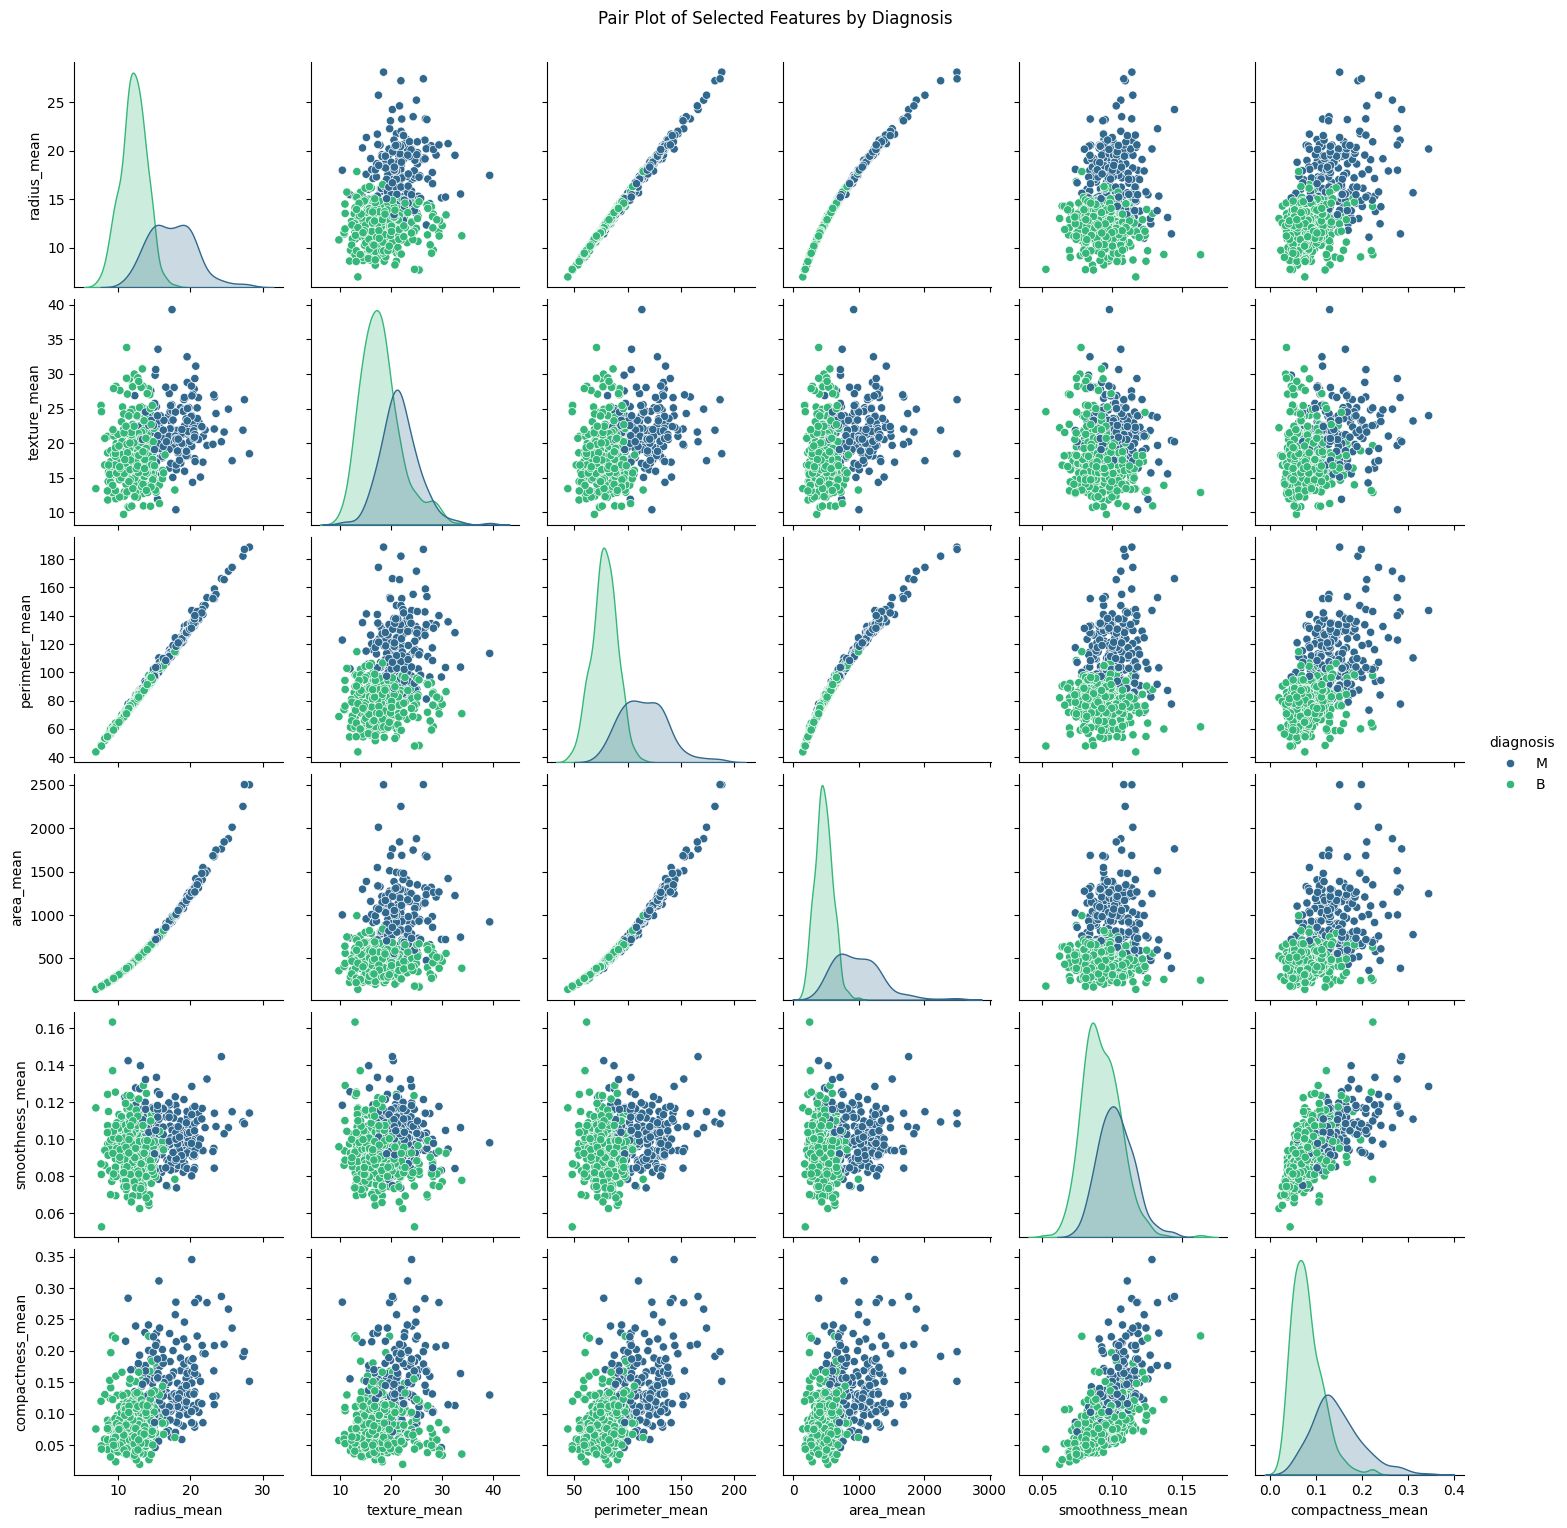

In [27]:
# Select a subset of features for the pair plot
features_for_pairplot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'diagnosis']

# Create a pair plot
sns.pairplot(df_cleaned[features_for_pairplot], hue='diagnosis', palette='viridis')
plt.suptitle('Pair Plot of Selected Features by Diagnosis', y=1.02) # Add a title to the plot
plt.show()